In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import kagglehub

In [2]:
path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pirom\.cache\kagglehub\datasets\usdot\flight-delays\versions\1


In [3]:
df1=pd.read_csv(f'{path}//airlines.csv')

In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   IATA_CODE  14 non-null     str  
 1   AIRLINE    14 non-null     str  
dtypes: str(2)
memory usage: 669.0 bytes


In [5]:
df1.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [6]:
df1.value_counts()

IATA_CODE  AIRLINE                     
UA         United Air Lines Inc.           1
AA         American Airlines Inc.          1
US         US Airways Inc.                 1
F9         Frontier Airlines Inc.          1
B6         JetBlue Airways                 1
OO         Skywest Airlines Inc.           1
AS         Alaska Airlines Inc.            1
NK         Spirit Air Lines                1
WN         Southwest Airlines Co.          1
DL         Delta Air Lines Inc.            1
EV         Atlantic Southeast Airlines     1
HA         Hawaiian Airlines Inc.          1
MQ         American Eagle Airlines Inc.    1
VX         Virgin America                  1
Name: count, dtype: int64

In [7]:
df2=pd.read_csv(f'{path}//airports.csv')

In [8]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    str    
 1   AIRPORT    322 non-null    str    
 2   CITY       322 non-null    str    
 3   STATE      322 non-null    str    
 4   COUNTRY    322 non-null    str    
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), str(5)
memory usage: 33.4 KB


In [9]:
df2.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [10]:
df2.value_counts()

IATA_CODE  AIRPORT                              CITY                            STATE  COUNTRY  LATITUDE  LONGITUDE 
ABE        Lehigh Valley International Airport  Allentown                       PA     USA      40.65236  -75.44040     1
ABI        Abilene Regional Airport             Abilene                         TX     USA      32.41132  -99.68190     1
ABQ        Albuquerque International Sunport    Albuquerque                     NM     USA      35.04022  -106.60919    1
ABR        Aberdeen Regional Airport            Aberdeen                        SD     USA      45.44906  -98.42183     1
ABY        Southwest Georgia Regional Airport   Albany                          GA     USA      31.53552  -84.19447     1
                                                                                                                       ..
WRG        Wrangell Airport                     Wrangell                        AK     USA      56.48433  -132.36982    1
WYS        Westerly State Air

In [11]:
df2=df2.dropna()

In [12]:
import folium


# Centro aproximado de EE.UU.
mapa = folium.Map(location=[39.5, -98.35], zoom_start=4)

# Agregar marcadores
for _, row in df2.iterrows():
    folium.Marker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        popup=f"{row['IATA_CODE']} - {row['AIRPORT']}",
        tooltip=row['CITY']
    ).add_to(mapa)

# Mostrar mapa
mapa

In [13]:
df3=pd.read_csv(f'{path}//flights.csv')

C:\Users\pirom\AppData\Local\Temp\ipykernel_11236\4046085735.py:1: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df3=pd.read_csv(f'{path}//flights.csv')


In [14]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [15]:
df3.sample(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
2209566,2015,5,20,3,OO,4582,N8828D,FAR,MSP,1925,...,2024.0,-4.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3869066,2015,8,28,5,DL,1527,N694DL,ATL,FLL,1600,...,1747.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5351996,2015,12,1,2,DL,2036,N307DQ,EYW,ATL,1744,...,1959.0,10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4676063,2015,10,19,1,AA,1791,N547UW,13930,11057,1150,...,1439.0,-28.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3736492,2015,8,20,4,B6,2016,N265JB,BUF,BOS,1341,...,1503.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df3.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [17]:
df3['DATE'] = pd.to_datetime(df3[['YEAR','MONTH', 'DAY']])

In [18]:
#columnas a eliminar
cols_drop = ['TAXI_OUT', 'TAXI_IN', 'WHEELS_ON', 'WHEELS_OFF', 'YEAR', 
                       'MONTH','DAY','DAY_OF_WEEK', 'AIR_SYSTEM_DELAY',
                       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
                       'WEATHER_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
                       'FLIGHT_NUMBER', 'TAIL_NUMBER', 'AIR_TIME']

df3 = df3.drop(columns=cols_drop)

In [19]:
df3['SCHEDULED_DEPARTURE'].sample(10)

4092425     809
4038114    1605
2462752    1411
3939002     710
4897563    1510
335783     2147
3346386    1021
4155105    1021
3604306    1422
2333086    1605
Name: SCHEDULED_DEPARTURE, dtype: int64

In [20]:
# Reemplazar inf y -inf por NaN
df3.replace([np.inf, -np.inf], np.nan, inplace=True)

# Eliminar las filas que contengan NaN
df3.dropna(inplace=True)

In [21]:
cols = ['DEPARTURE_TIME', 'ARRIVAL_TIME', 'SCHEDULED_DEPARTURE']

for col in cols:
    df3[col] = pd.to_datetime(
        df3[col].astype(int).astype(str).str.zfill(4),
        format='%H%M',
        errors='coerce'
    ).dt.strftime('%H:%M')


In [22]:
df3['DEPARTURE_DELAY'].sample(10)

4676459    -2.0
466055     -4.0
2886463     6.0
3670861    -7.0
1311513     1.0
3795063    -6.0
977473     -7.0
2723561   -13.0
3294366    -6.0
168683     75.0
Name: DEPARTURE_DELAY, dtype: float64

In [23]:
df3['ARRIVAL_DELAY'].sample(10)

4759509     -2.0
3926279    -16.0
5341866     -6.0
1367098    -28.0
4651585      8.0
3818295    -11.0
3786308    -32.0
4215717    -13.0
5331461     -7.0
5547782    105.0
Name: ARRIVAL_DELAY, dtype: float64

In [24]:
df3[:5]

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_TIME,ELAPSED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DATE
0,AS,ANC,SEA,00:05,23:54,-11.0,205.0,194.0,1448,430,04:08,-22.0,2015-01-01
1,AA,LAX,PBI,00:10,00:02,-8.0,280.0,279.0,2330,750,07:41,-9.0,2015-01-01
2,US,SFO,CLT,00:20,00:18,-2.0,286.0,293.0,2296,806,08:11,5.0,2015-01-01
3,AA,LAX,MIA,00:20,00:15,-5.0,285.0,281.0,2342,805,07:56,-9.0,2015-01-01
4,AS,SEA,ANC,00:25,00:24,-1.0,235.0,215.0,1448,320,02:59,-21.0,2015-01-01


In [25]:
#nombres de aerolineas
airlines = {
    'VX':'Virgin America',
    'HA':'Hawaiian Airlines Inc.',
    'F9':'Frontier Airlines Inc.',
    'NK':'Spirit Air Lines',
    'AS':'Alaska Airlines Inc.',
    'B6':'JetBlue Airways',
    'MQ':'American Eagle Airlines Inc.',
    'US':'US Airways Inc.',
    'UA':'United Air Lines Inc.',
    'AA':'American Airlines Inc.',
    'OO':'Skywest Airlines Inc.',
    'EV':'Atlantic Southeast Airlines',
    'DL':'Delta Air Lines Inc.',
    'WN':'Southwest Airlines Co.'
}

In [26]:
summary = (
    df3.groupby('AIRLINE')['DEPARTURE_DELAY']
    .agg(['min', 'max', 'count', 'mean'])
    .sort_values('mean')
)

summary

,min,max,count,mean
AIRLINE,,,,
HA,-27.0,1433.0,76041,0.469918
AS,-82.0,963.0,171439,1.718926
US,-28.0,759.0,194223,6.081000
DL,-61.0,1289.0,870275,7.313300
OO,-56.0,1378.0,576814,7.736083
EV,-55.0,1236.0,554752,8.615598
AA,-68.0,1988.0,712935,8.826106
VX,-24.0,644.0,61248,8.993486
MQ,-36.0,1544.0,278791,9.967187


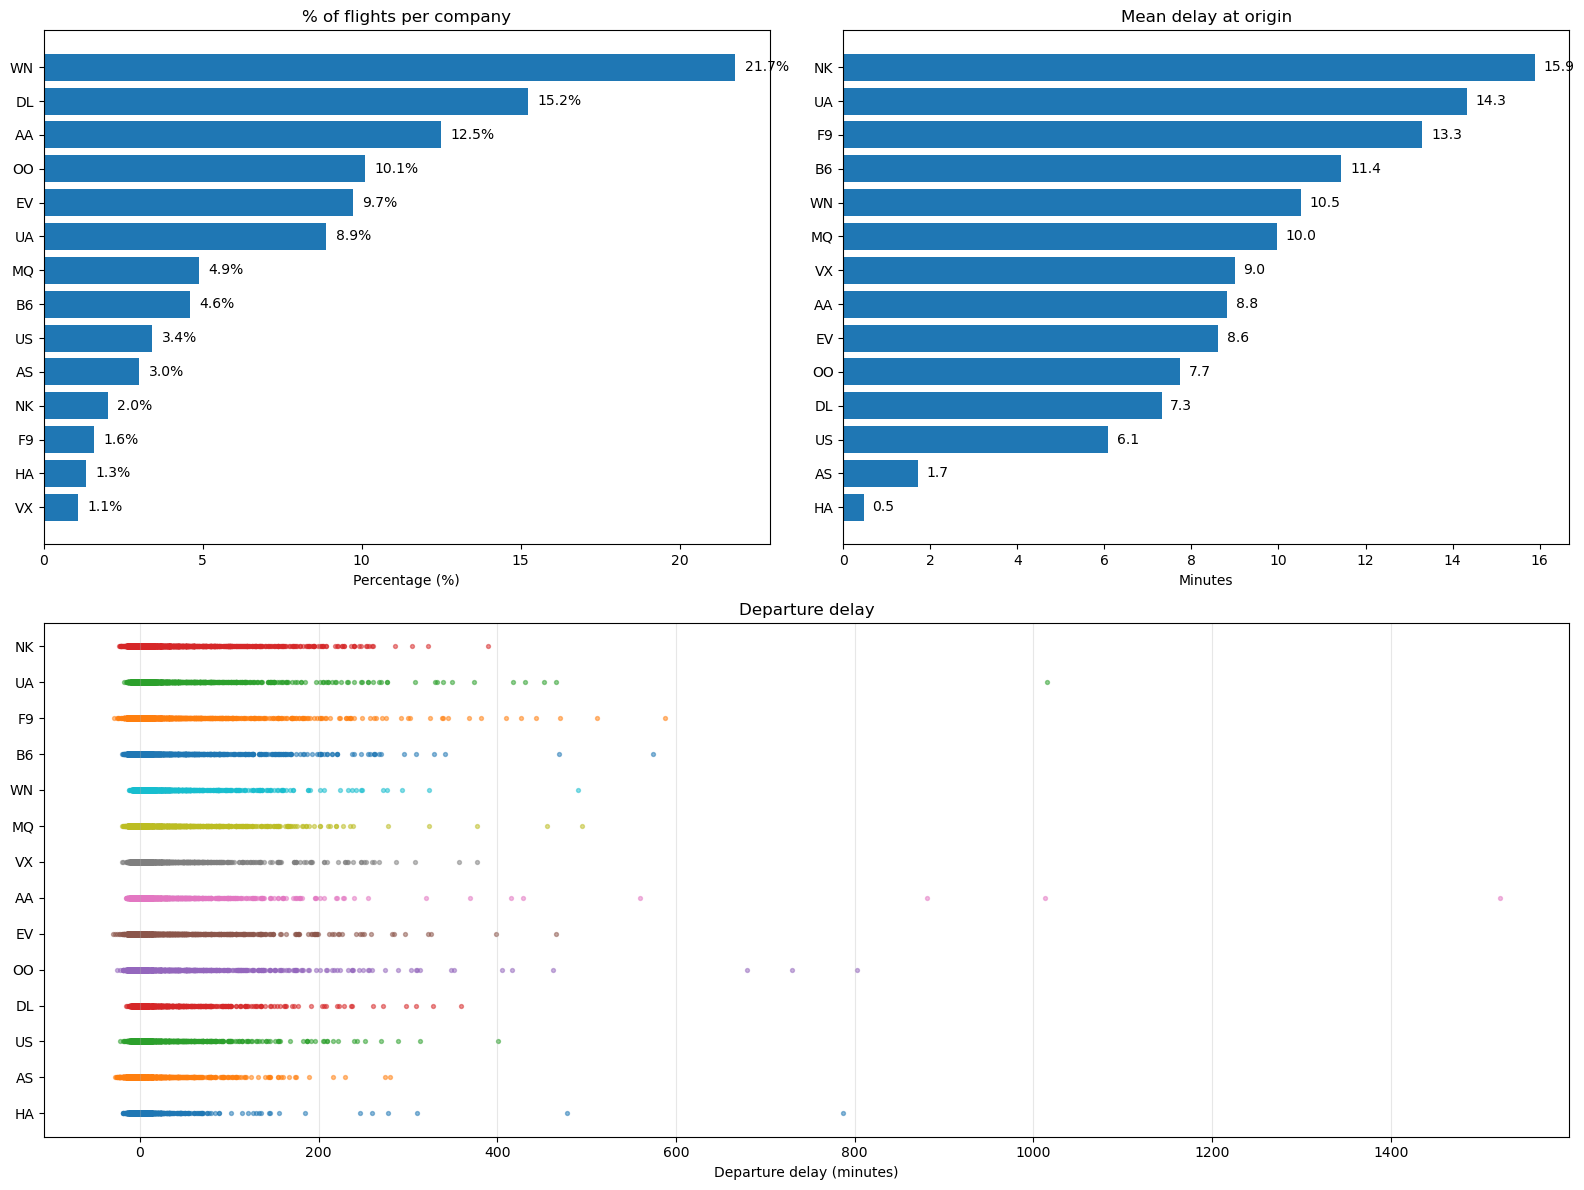

In [27]:
fig = plt.figure(figsize=(16,12))

# ==========================
# BAR 1 - % vuelos
# ==========================

ax1 = plt.subplot2grid((2,2),(0,0))

flight_pct = (
    df3['AIRLINE']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

bars1 = ax1.barh(
    flight_pct.index,
    flight_pct.values
)

ax1.set_title('% of flights per company')
ax1.set_xlabel('Percentage (%)')

for bar in bars1:
    width = bar.get_width()
    ax1.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center'
    )

# ==========================
# BAR 2 - retraso promedio
# ==========================

ax2 = plt.subplot2grid((2,2),(0,1))

mean_delay = (
    df3.groupby('AIRLINE')['DEPARTURE_DELAY']
    .mean()
    .sort_values()
)

bars2 = ax2.barh(
    mean_delay.index,
    mean_delay.values
)

ax2.set_title('Mean delay at origin')
ax2.set_xlabel('Minutes')

for bar in bars2:
    width = bar.get_width()
    ax2.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',
        va='center'
    )

# ==========================
# SCATTER retrasos
# ==========================

ax3 = plt.subplot2grid((2,2),(1,0), colspan=2)

airline_order = summary.index

for i, airline in enumerate(airline_order):

    sample = df3.loc[
        df3['AIRLINE'] == airline,
        'DEPARTURE_DELAY'
    ]

    sample = sample.dropna()

    if len(sample) > 3000:
        sample = sample.sample(
            3000,
            random_state=42
        )

    y = np.full(len(sample), i)

    ax3.scatter(
        sample,
        y,
        alpha=0.5,
        s=8
    )

ax3.set_yticks(range(len(airline_order)))
ax3.set_yticklabels(airline_order)

ax3.set_xlabel('Departure delay (minutes)')
ax3.set_title('Departure delay')

ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
delay_type = lambda x:((0,1)[x > 5],2)[x > 45]
df3['DELAY_LEVEL'] = df3['DEPARTURE_DELAY'].apply(delay_type)
df3['DELAY_LEVEL'].sample(10)

2841747    2
5460446    0
4929135    0
1236186    0
3480259    0
26217      0
3492035    0
2629699    0
2152173    0
2573501    0
Name: DELAY_LEVEL, dtype: int64

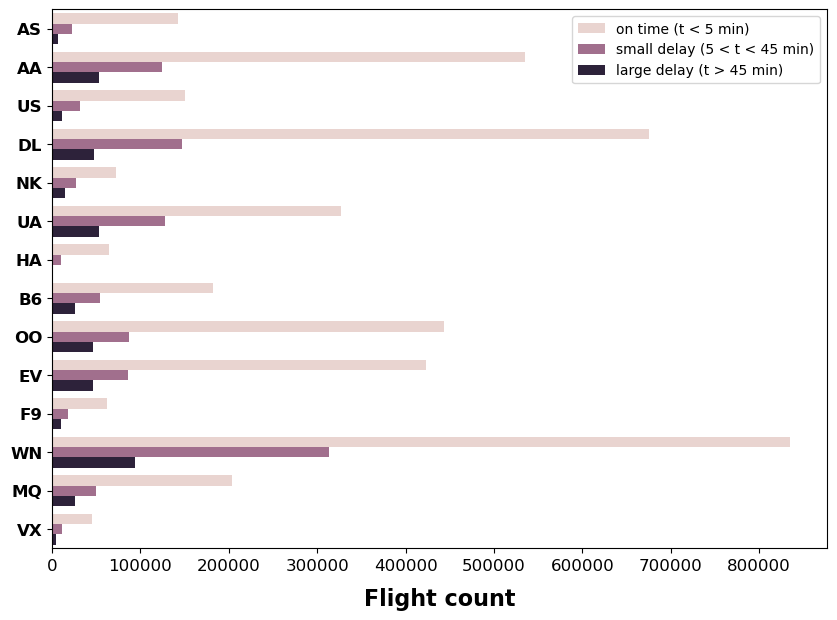

In [29]:
#revisar los retrasos de los aeropuertos
fig = plt.figure(1, figsize=(10,7))
ax = sns.countplot(y="AIRLINE", hue='DELAY_LEVEL', data=df3)

labels = df3['AIRLINE']
plt.setp(ax.get_xticklabels(), fontsize=12, weight = 'normal', rotation = 0);
plt.setp(ax.get_yticklabels(), fontsize=12, weight = 'bold', rotation = 0);
ax.yaxis.label.set_visible(False)
plt.xlabel('Flight count', fontsize=16, weight = 'bold', labelpad=10)

L = plt.legend()
L.get_texts()[0].set_text('on time (t < 5 min)')
L.get_texts()[1].set_text('small delay (5 < t < 45 min)')
L.get_texts()[2].set_text('large delay (t > 45 min)')
plt.show()

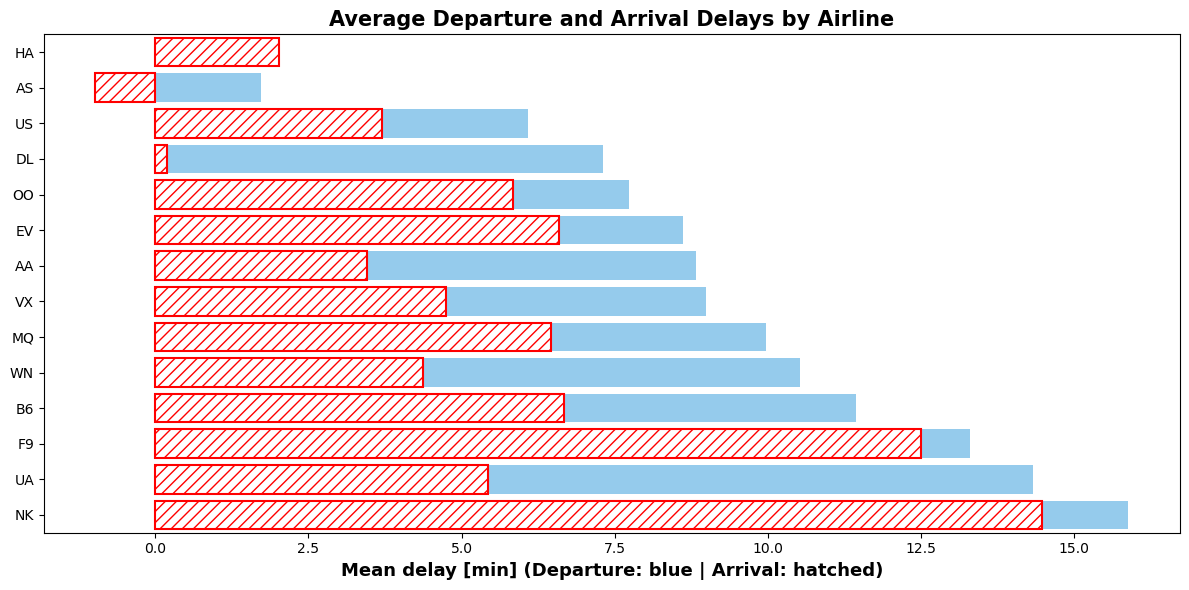

In [30]:
plt.figure(figsize=(12, 6))

# Retraso promedio de salida
order = (
    df3.groupby('AIRLINE')['DEPARTURE_DELAY']
    .mean()
    .sort_values()
    .index
)
ax = sns.barplot(
    data=df3,
    x='DEPARTURE_DELAY',
    y='AIRLINE',
    order=order,
    estimator='mean',
    errorbar=None,
    color='lightskyblue'
)

# Retraso promedio de llegada
sns.barplot(
    data=df3,
    x="ARRIVAL_DELAY",
    y="AIRLINE",
    order=order,
    estimator='mean',
    errorbar=None,
    color='white',
    edgecolor='red',
    hatch='///',
    linewidth=1.5,
    ax=ax
)

ax.set_ylabel('')
ax.set_xlabel(
    'Mean delay [min] (Departure: blue | Arrival: hatched)',
    fontsize=13,
    fontweight='bold'
)

ax.set_title('Average Departure and Arrival Delays by Airline',
             fontsize=15,
             fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
top_airports = (
    df3['ORIGIN_AIRPORT']
    .value_counts()
    .head(40)
    .index
)

df_heatmap = df3[
    df3['ORIGIN_AIRPORT'].isin(top_airports)
]

In [32]:
airport_delay_matrix = pd.pivot_table(
    df_heatmap,
    values='DEPARTURE_DELAY',
    index='ORIGIN_AIRPORT',
    columns='AIRLINE',
    aggfunc='mean'
)
airport_delay_matrix.head()

AIRLINE,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
ORIGIN_AIRPORT,,,,,,,,,,,,,,
ATL,6.420524,5.707944,NaN,7.869319,10.142603,21.878224,NaN,17.005093,23.441995,13.471992,17.175227,4.169439,NaN,12.715725
AUS,8.066343,8.240000,10.925057,8.524337,3.585139,16.234855,NaN,NaN,NaN,11.959005,13.903478,11.263043,5.404380,10.097174
BNA,7.873020,3.470588,NaN,7.311582,7.708955,7.566978,NaN,13.443462,NaN,11.683219,12.673317,3.046477,NaN,10.007993
BOS,4.972403,4.297395,9.405077,11.990645,8.505425,NaN,NaN,NaN,15.113615,10.226190,14.595165,5.096060,7.114786,12.386328
BWI,9.235700,7.327670,3.949827,8.701005,7.082353,NaN,NaN,17.206136,18.905347,156.000000,12.582403,5.708155,NaN,14.253529


In [33]:
airport_order = (
    airport_delay_matrix
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

airport_delay_matrix = airport_delay_matrix.loc[
    airport_order
]

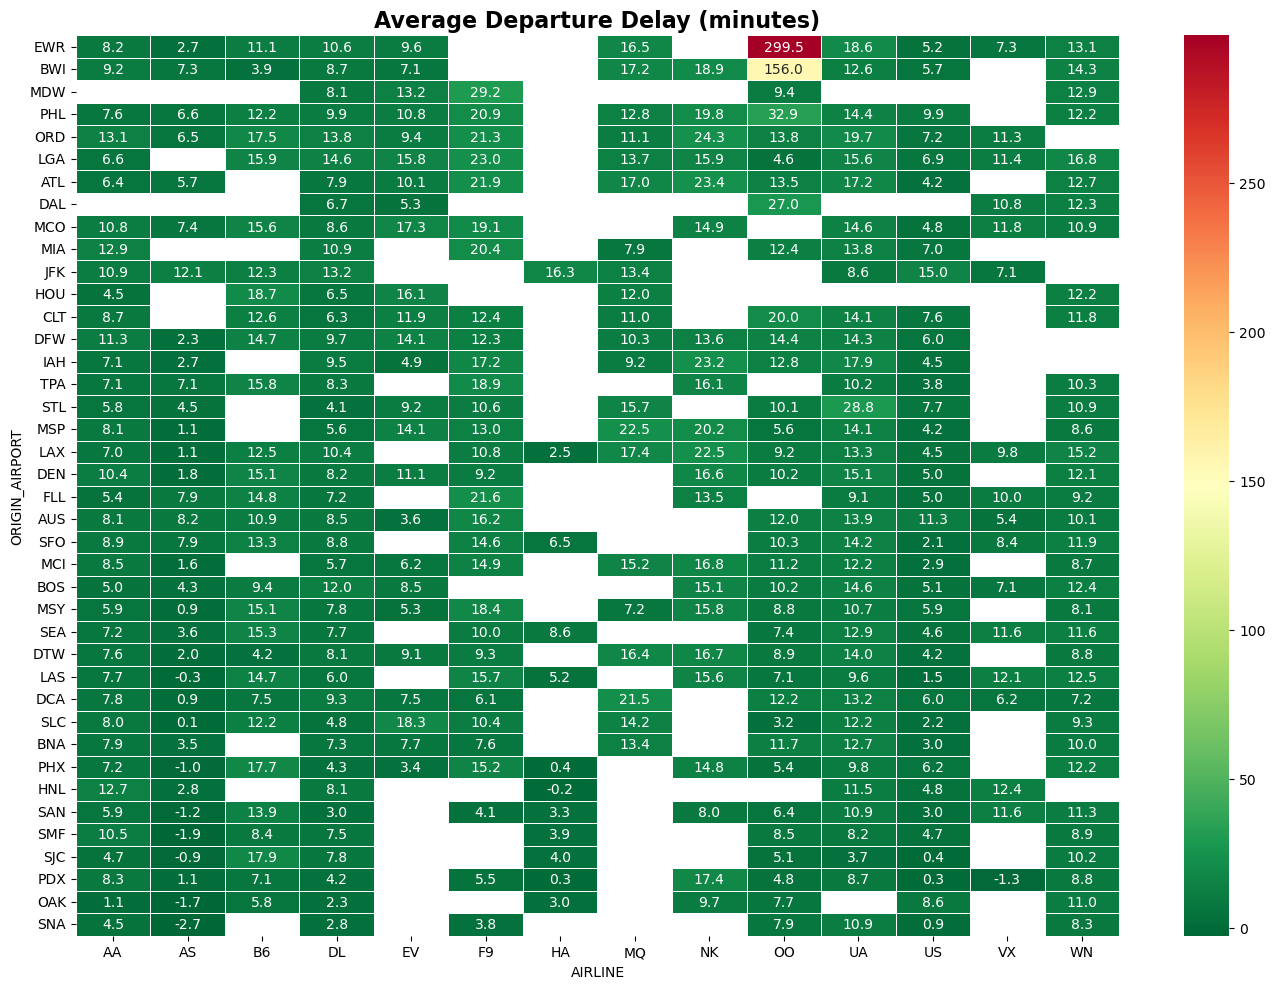

In [34]:
#heatmap para observar el retraso promedio en minutos
plt.figure(figsize=(14,10))

sns.heatmap(
    airport_delay_matrix,
    cmap='RdYlGn_r',
    linewidths=0.5,
    annot=True,
    fmt='.1f'
)

plt.title(
    'Average Departure Delay (minutes)',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [35]:
df3.head()

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_TIME,ELAPSED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DATE,DELAY_LEVEL
0,AS,ANC,SEA,00:05,23:54,-11.0,205.0,194.0,1448,430,04:08,-22.0,2015-01-01,0
1,AA,LAX,PBI,00:10,00:02,-8.0,280.0,279.0,2330,750,07:41,-9.0,2015-01-01,0
2,US,SFO,CLT,00:20,00:18,-2.0,286.0,293.0,2296,806,08:11,5.0,2015-01-01,0
3,AA,LAX,MIA,00:20,00:15,-5.0,285.0,281.0,2342,805,07:56,-9.0,2015-01-01,0
4,AS,SEA,ANC,00:25,00:24,-1.0,235.0,215.0,1448,320,02:59,-21.0,2015-01-01,0


In [36]:
delay_ts = df3.groupby('DATE')['ARRIVAL_DELAY'].mean().reset_index()
delay_ts['DATE'] = pd.to_datetime(delay_ts['DATE'])

delay_ts = delay_ts.set_index('DATE')
delay_ts.head()

,ARRIVAL_DELAY
DATE,
2015-01-01,5.352496
2015-01-02,9.838904
2015-01-03,25.461860
2015-01-04,31.975011
2015-01-05,18.811310


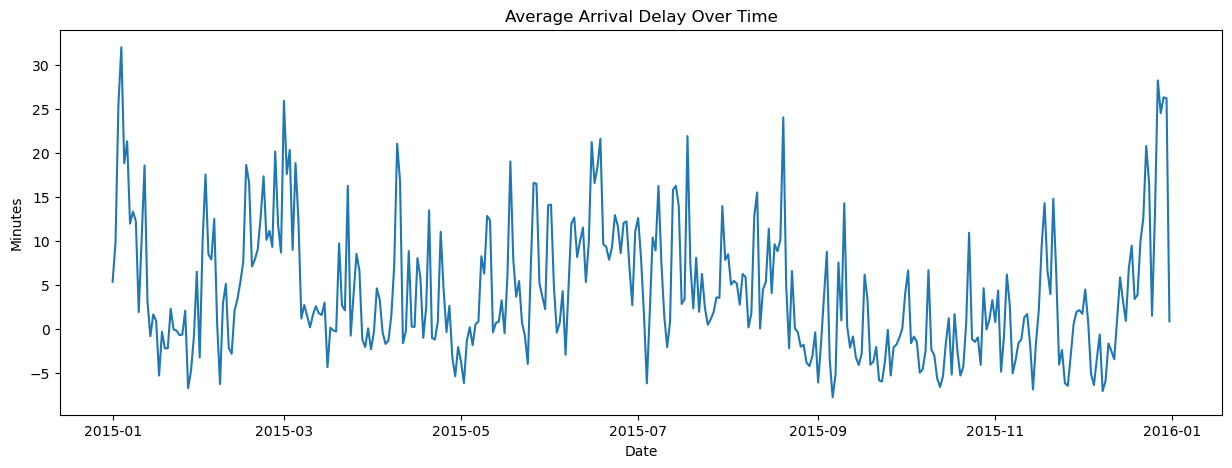

In [37]:
#grafica del delay promedio por dia
plt.figure(figsize=(15,5))

plt.plot(
    delay_ts.index,
    delay_ts['ARRIVAL_DELAY']
)

plt.title('Average Arrival Delay Over Time')
plt.ylabel('Minutes')
plt.xlabel('Date')

plt.show()

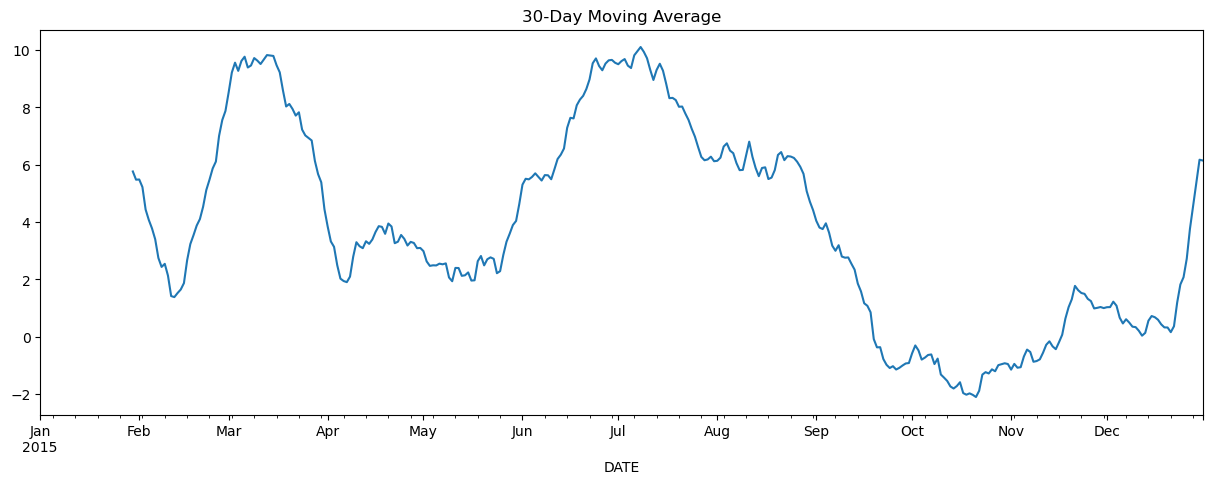

In [38]:
#suavizado de la tendencia
plt.figure(figsize=(15,5))

delay_ts['ARRIVAL_DELAY'].rolling(
    30
).mean().plot()

plt.title('30-Day Moving Average')
plt.show()

In [39]:
#creacion de variables temporales para machine learning
ts = delay_ts.copy()

for lag in [1, 7, 14, 21, 28, 30]:
    ts[f'lag_{lag}'] = ts['ARRIVAL_DELAY'].shift(lag)

ts['rolling_7'] = (
    ts['ARRIVAL_DELAY']
    .shift(1)
    .rolling(7)
    .mean()
)
ts['rolling_14'] = (
    ts['ARRIVAL_DELAY']
    .shift(1)
    .rolling(14)
    .mean()
)
ts['rolling_30'] = (
    ts['ARRIVAL_DELAY']
    .shift(1)
    .rolling(30)
    .mean()
)

ts['rolling_std_7'] = (
    ts['ARRIVAL_DELAY']
    .shift(1)
    .rolling(7)
    .std()
)

ts['rolling_std_30'] = (
    ts['ARRIVAL_DELAY']
    .shift(1)
    .rolling(30)
    .std()
)

ts['ewm_7'] = (
    ts['ARRIVAL_DELAY']
    .shift(1)
    .ewm(span=7)
    .mean()
)

ts['dayofweek'] = ts.index.dayofweek
ts['dayofyear'] = ts.index.dayofyear



ts['dayofweek_sin'] = np.sin(
    2*np.pi*ts['dayofweek']/7
)


ts['dayofyear_sin'] = np.sin(
    2 * np.pi * ts['dayofyear'] / 365
)

ts['dayofyear_cos'] = np.cos(
    2 * np.pi * ts['dayofyear'] / 365
)



ts = ts.dropna()

In [40]:
#seleccionar las variables y el target


features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_28',
    'rolling_7',
    'rolling_std_7',
    'ewm_7',
    'dayofweek_sin',
    'dayofyear_sin',
    'dayofyear_cos'
]

X = ts[features]
y = ts['ARRIVAL_DELAY']

In [41]:
#dividir en train test
split = int(len(ts) * 0.8)

X = ts[features]
y = ts['ARRIVAL_DELAY']

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [42]:
#validacion para time series

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

# Visualizar los folds
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    print(
        f'Fold {fold+1}: '
        f'Train={len(train_idx)} '
        f'Test={len(test_idx)}'
    )

Fold 1: Train=48 Test=44
Fold 2: Train=92 Test=44
Fold 3: Train=136 Test=44
Fold 4: Train=180 Test=44
Fold 5: Train=224 Test=44


In [43]:
#modelo de ridge
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {
    'alpha': np.logspace(-4, 4, 50)
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

In [44]:
#modelo de ElasticNet
from sklearn.linear_model import ElasticNet

elastic_params = {
    'alpha': np.logspace(-4, 1, 20),
    'l1_ratio': [0.1,0.3,0.5,0.7,0.9]
}

elastic_grid = GridSearchCV(
    ElasticNet(max_iter=10000),
    elastic_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

elastic_grid.fit(X_train, y_train)

best_elastic = elastic_grid.best_estimator_

elastic_pred = best_elastic.predict(X_test)


In [45]:
#modelo de random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf_params = {
    'n_estimators': [300,500,800],
    'max_depth': [5,10,15,None],
    'min_samples_leaf': [1,2,5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42
    ),
    rf_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)

In [46]:
#modelo de XGBRegressor
from xgboost import XGBRegressor

xgb_params = {
    'n_estimators': [200,500,1000],
    'max_depth': [2,3,5],
    'learning_rate': [0.01,0.03,0.05],
    'subsample': [0.8,1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        random_state=42
    ),
    xgb_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

xgb_pred = best_xgb.predict(X_test)

In [47]:
#modelo de LGBMRegressor
from lightgbm import LGBMRegressor


lgbm_params = {
    'n_estimators': [200,500,1000],
    'max_depth': [3,5,7,-1],
    'learning_rate': [0.01,0.03,0.05]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(
        random_state=42
    ),
    lgbm_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lgbm_grid.fit(X_train, y_train)

best_lgbm = lgbm_grid.best_estimator_

lgbm_pred = best_lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 901
[LightGBM] [Info] Number of data points in the train set: 268, number of used features: 11
[LightGBM] [Info] Start training from score 4.421546
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [48]:
#comparativa de desempeño de modelos
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = pd.DataFrame([
    {
        'Model':'Ridge',
        'MAE':mean_absolute_error(y_test, ridge_pred),
        'RMSE':np.sqrt(mean_squared_error(y_test, ridge_pred)),
        'R2':r2_score(y_test, ridge_pred)
    },
    {
        'Model':'ElasticNet',
        'MAE':mean_absolute_error(y_test, elastic_pred),
        'RMSE':np.sqrt(mean_squared_error(y_test, elastic_pred)),
        'R2':r2_score(y_test, elastic_pred)
    },
    {
        'Model':'Random Forest',
        'MAE':mean_absolute_error(y_test, rf_pred),
        'RMSE':np.sqrt(mean_squared_error(y_test, rf_pred)),
        'R2':r2_score(y_test, rf_pred)
    },
    {
        'Model':'XGBoost',
        'MAE':mean_absolute_error(y_test, xgb_pred),
        'RMSE':np.sqrt(mean_squared_error(y_test, xgb_pred)),
        'R2':r2_score(y_test, xgb_pred)
    },
    {
        'Model':'LightGBM',
        'MAE':mean_absolute_error(y_test, lgbm_pred),
        'RMSE':np.sqrt(mean_squared_error(y_test, lgbm_pred)),
        'R2':r2_score(y_test, lgbm_pred)
    }
])

results.sort_values('RMSE')

,Model,MAE,RMSE,R2
1,ElasticNet,4.570745,6.248560,0.427702
0,Ridge,4.578111,6.267941,0.424146
3,XGBoost,4.908426,6.490313,0.382561
2,Random Forest,5.031242,6.578615,0.365646
4,LightGBM,4.921146,6.591250,0.363207


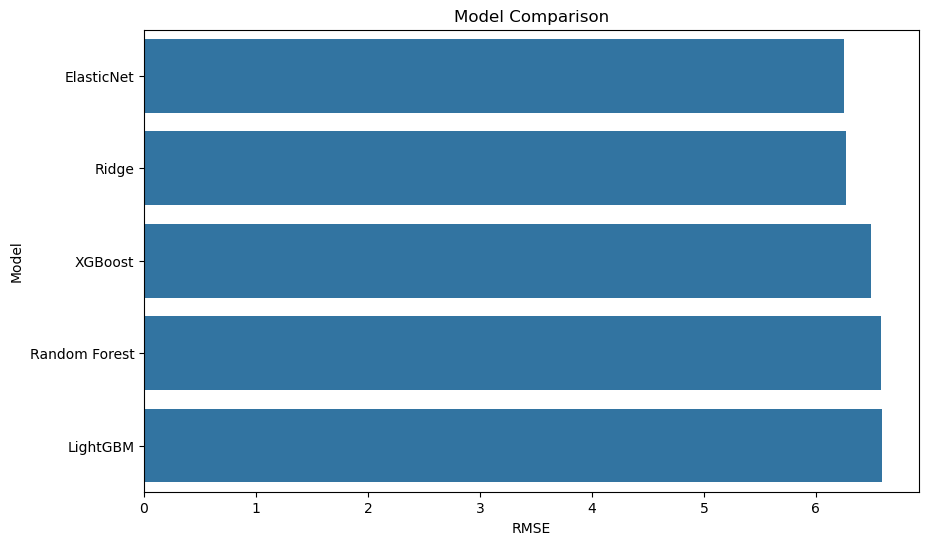

In [49]:
#grafica de comparativa de desempeño
plt.figure(figsize=(10,6))

sns.barplot(
    data=results.sort_values('RMSE'),
    x='RMSE',
    y='Model'
)

plt.title('Model Comparison')
plt.show()

In [50]:
#coeficientes de ElasticNet
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_elastic.coef_
})

coef_df['AbsCoef'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    'AbsCoef',
    ascending=False
)

coef_df

,Feature,Coefficient,AbsCoef
0,lag_1,0.445530,0.445530
6,rolling_std_7,-0.288010,0.288010
5,rolling_7,0.194715,0.194715
3,lag_21,0.125366,0.125366
4,lag_28,0.104581,0.104581
1,lag_7,0.096865,0.096865
2,lag_14,0.030723,0.030723
7,ewm_7,0.000000,0.000000
8,dayofweek_sin,0.000000,0.000000
9,dayofyear_sin,0.000000,0.000000


In [51]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(delay_ts['ARRIVAL_DELAY'])

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

if adf_result[1] < 0.05:
    print('\nLa serie es estacionaria')
else:
    print('\nLa serie NO es estacionaria')

ADF Statistic: -4.360103402996977
p-value: 0.00034899412260730873

La serie es estacionaria


<Figure size 1200x500 with 0 Axes>

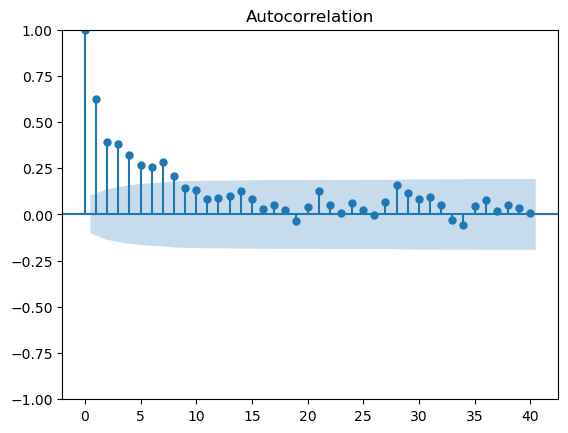

In [52]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    delay_ts['ARRIVAL_DELAY'],
    lags=40
)

plt.title('Autocorrelation')

plt.show()

<Figure size 1200x500 with 0 Axes>

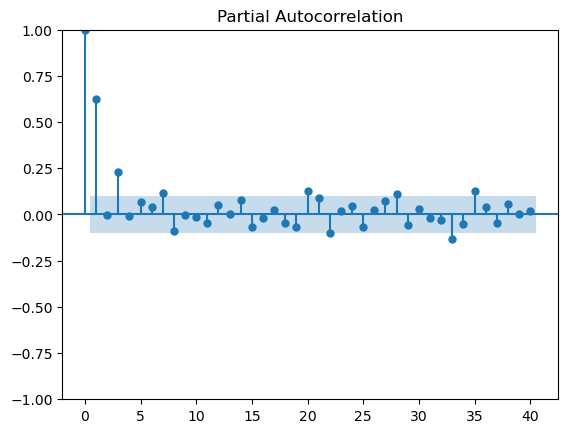

In [53]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    delay_ts['ARRIVAL_DELAY'],
    lags=40,
    method='ywm'
)

plt.title('Partial Autocorrelation')

plt.show()

In [54]:
#crear nuevas variables importantes
from holidays import US
ts['lag_2'] = (
    ts['ARRIVAL_DELAY']
    .shift(2)
)


us_holidays = US()

ts['is_holiday'] = (
    ts.index.to_series()
    .apply(lambda x: x in us_holidays)
    .astype(int)
)

ts = ts.dropna()

In [55]:
features_final = [
    'lag_1',
    'lag_2',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_28',
    'rolling_7',
    'rolling_std_7',
    'is_holiday'
]

In [56]:
X = ts[features_final]

y = ts['ARRIVAL_DELAY']

split = int(len(ts)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [57]:
tscv = TimeSeriesSplit(
    n_splits=5
)

In [58]:
param_grid = {
    'alpha': np.logspace(-4,1,20),
    'l1_ratio':[0.1,0.3,0.5,0.7,0.9]
}

grid = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train,y_train)

best_elastic = grid.best_estimator_

In [59]:
elastic_pred = best_elastic.predict(X_test)

In [60]:
mae = mean_absolute_error(
    y_test,
    elastic_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        elastic_pred
    )
)

r2 = r2_score(
    y_test,
    elastic_pred
)

print(f'MAE : {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²  : {r2:.3f}')

MAE : 4.553
RMSE: 6.212
R²  : 0.434


In [61]:
# importancia de coeficientes
coef_df = pd.DataFrame({
    'Feature': features_final,
    'Coefficient': best_elastic.coef_
})

coef_df['AbsCoef'] = (
    coef_df['Coefficient']
    .abs()
)

coef_df = coef_df.sort_values(
    'AbsCoef',
    ascending=False
)

coef_df

,Feature,Coefficient,AbsCoef
0,lag_1,0.453382,0.453382
7,rolling_std_7,-0.253967,0.253967
6,rolling_7,0.229327,0.229327
4,lag_21,0.117857,0.117857
5,lag_28,0.102657,0.102657
2,lag_7,0.091858,0.091858
1,lag_2,-0.045057,0.045057
3,lag_14,0.034214,0.034214
8,is_holiday,-0.000000,0.000000


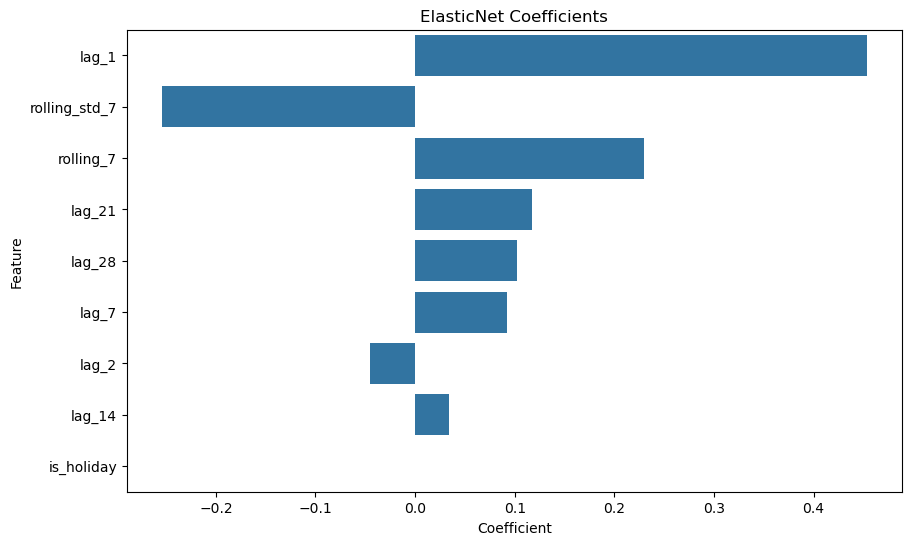

In [62]:
# grafica de importancia de coeficientes
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature'
)

plt.title(
    'ElasticNet Coefficients'
)

plt.show()

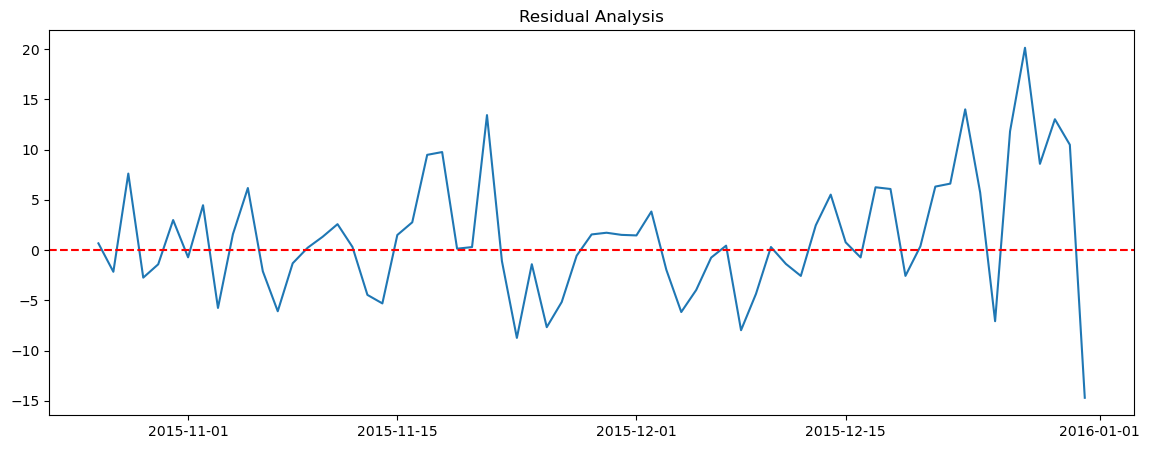

In [63]:
#grafica de residuos
residuals = (
    y_test -
    elastic_pred
)

plt.figure(figsize=(14,5))

plt.plot(
    y_test.index,
    residuals
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title(
    'Residual Analysis'
)

plt.show()

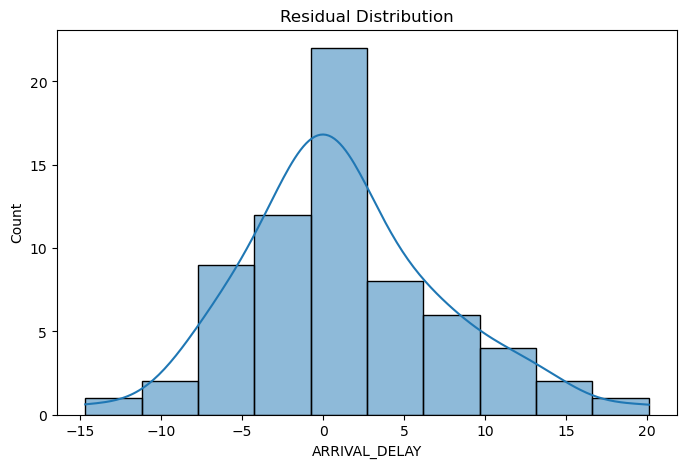

In [64]:
#distribucion residual
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    'Residual Distribution'
)

plt.show()

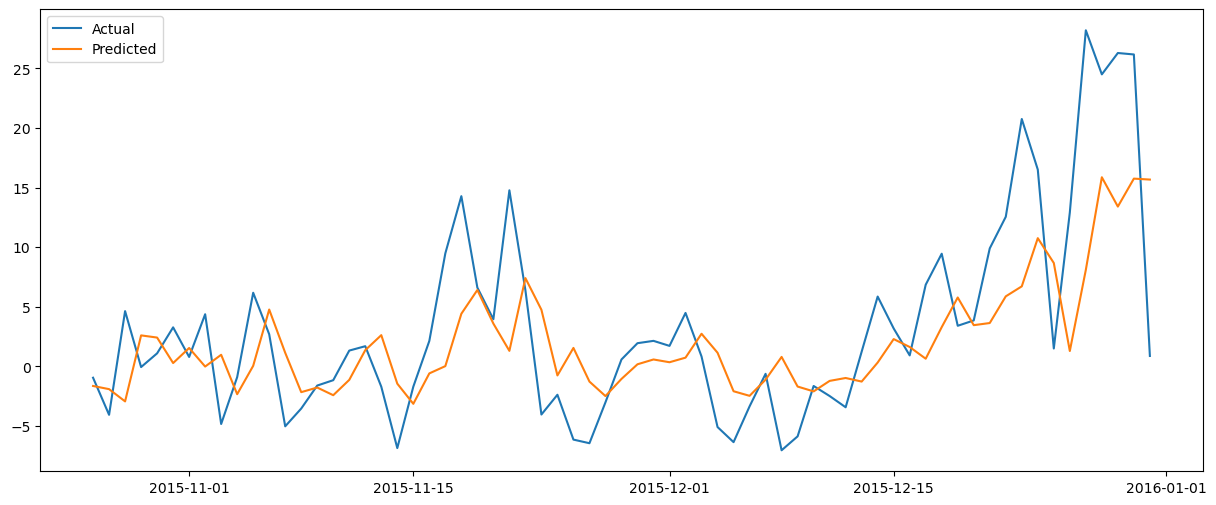

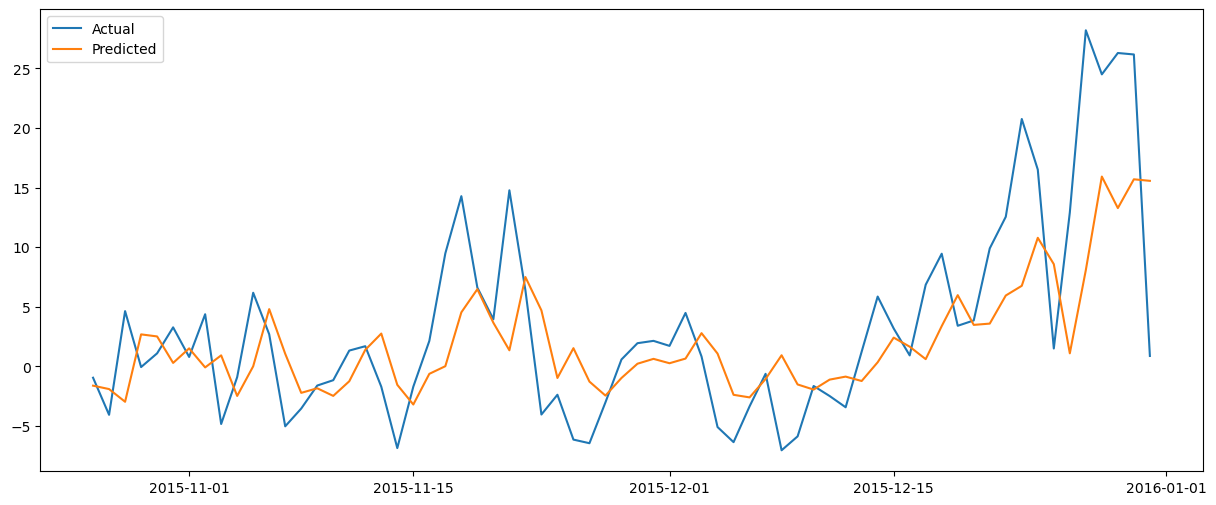

In [ ]:
#prediccion vs real
plt.figure(figsize=(15,6))

plt.plot(
    y_test.index,
    y_test,
    label='Actual'
)

plt.plot(
    y_test.index,
    elastic_pred,
    label='Predicted'
)

plt.legend()
plt.show()